In [1]:
pip install torch torchvision torchaudio pillow matplotlib pyyaml scikit-learn seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import glob
import yaml
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [14]:
data_path = '.' 
yaml_path = os.path.join(data_path, 'data.yaml')

class TrafficSignDataset(Dataset):
    def init(self, root_dir, split='train',transform=None):
        self.images_dir = os.path.join(root_dir, split, 'images')
        self.labels_dir = os.path.join(root_dir, split, 'labels')
        self.transform = transform

        #cautarea imaginior
        self.image_files = glob.glob(os.path.join(self.images_dir, "*.jpg")) + \
                           glob.glob(os.path.join(self.images_dir, "*.png")) + \
                           glob.glob(os.path.join(self.images_dir, "*.jpeg"))

    def len(self):
        return len(self.image_files)

    def getitem(self, idx):
        img_path = self.image_files[idx]
        image = Image.open(img_path).convert("RGB")

        filename = os.path.basename(img_path)
        label_name = os.path.splitext(filename)[0] + ".txt"
        label_path = os.path.join(self.labels_dir, label_name)

        label = 0 
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                content = f.readline().split()
                if content:
                    label = int(content[0])

        if self.transform:
            image = self.transform(image)

        return image, label

In [3]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    
    #denoising
    transforms.GaussianBlur(kernel_size=(3,3),sigma=(0.1,2.0)),
    
    #ajustarea claritatii
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),
    
    #augmentarea datelor pentru robustete
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    
    #standardizare
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_dataset = TrafficSignDataset(DATA_PATH, split='train', transform=transform)
valid_dataset = TrafficSignDataset(DATA_PATH, split='valid', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)

print(f"Imaginile de antrenare: {len(train_dataset)}")
print(f"Imaginile de validare: {len(valid_dataset)}")

Imagini antrenare: 3530
Imagini validare: 801


In [29]:
class CustomTrafficNet(nn.Module):
    def __init__(self, num_classes=10):
        super(CustomTrafficNet, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2), 
            nn.Conv2d(16, 32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2), 
            nn.Conv2d(32, 64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2) 
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(64*8*8,128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

In [31]:
try:
    with open(yaml_path, 'r') as f:
        data_yaml = yaml.safe_load(f)
    classes = data_yaml['names']
    num_classes2 = len(classes)
    print(f"Au fost gasite: {num_classes2} clase: {classes}")
except:
    NUM_CLASSES = 15 
    classes = [str(i) for i in range(num_classes2)]
    print("Fisierul nu s-a putut citi")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomTrafficNet(num_classes=num_classes2).to(device)

Au fost gasite: 15 clase: ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100', 'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30', 'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70', 'Speed Limit 80', 'Speed Limit 90', 'Stop']


In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 15 

train_losses = []
valid_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    acc = 100 * correct / total
    train_losses.append(running_loss/len(train_loader))
    valid_accuracies.append(acc)
    print(f"Epoca {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f} - Acuratete: {acc:.2f}%")
    
    torch.save(model.state_dict(), 'traffic_sign_model_local4.pth')
    

Epoca 1/15 - Loss: 2.3983 - Acuratete: 33.21%
Epoca 2/15 - Loss: 1.9808 - Acuratete: 33.58%
Epoca 3/15 - Loss: 1.8306 - Acuratete: 39.58%
Epoca 4/15 - Loss: 1.6968 - Acuratete: 42.20%
Epoca 5/15 - Loss: 1.5578 - Acuratete: 42.57%
Epoca 6/15 - Loss: 1.4116 - Acuratete: 48.06%
Epoca 7/15 - Loss: 1.2640 - Acuratete: 52.93%
Epoca 8/15 - Loss: 1.1216 - Acuratete: 52.68%
Epoca 9/15 - Loss: 0.9526 - Acuratete: 56.68%
Epoca 10/15 - Loss: 0.8507 - Acuratete: 55.56%
Epoca 11/15 - Loss: 0.7395 - Acuratete: 61.42%
Epoca 12/15 - Loss: 0.6587 - Acuratete: 60.55%
Epoca 13/15 - Loss: 0.5740 - Acuratete: 61.30%
Epoca 14/15 - Loss: 0.5139 - Acuratete: 62.67%
Epoca 15/15 - Loss: 0.4598 - Acuratete: 64.79%


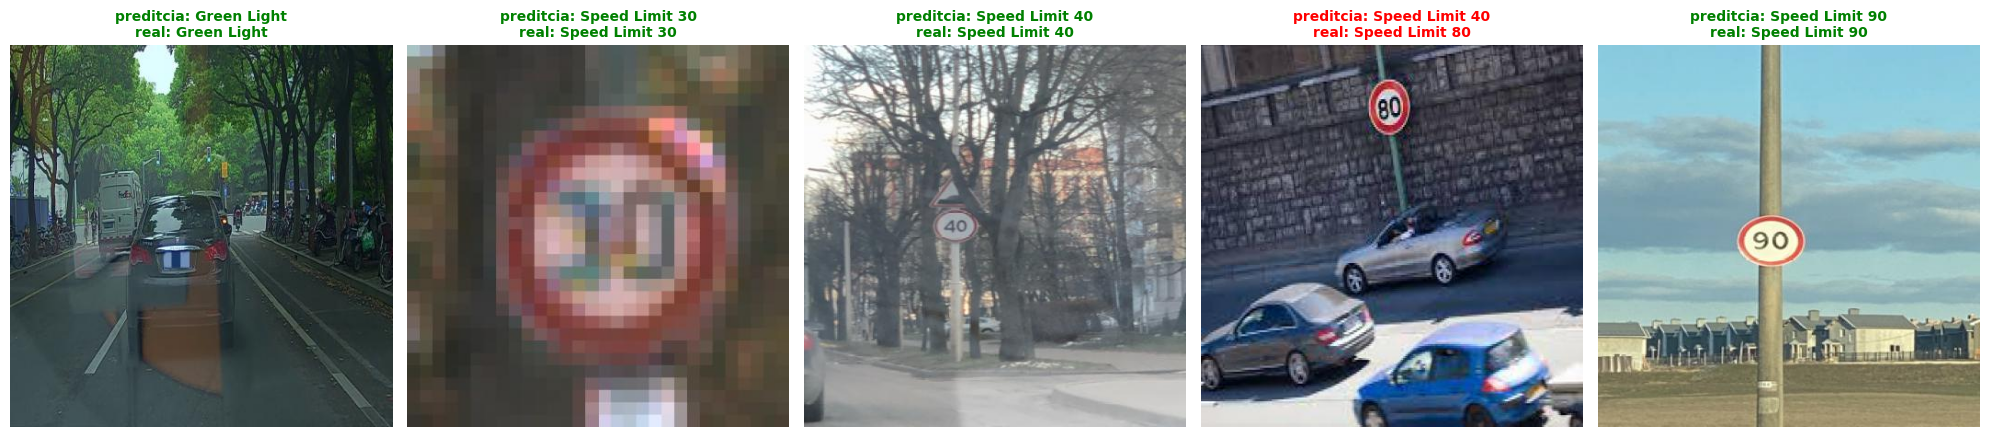

In [34]:
import random
import os

def visualize_results_with_labels(model, dataset_path, split='test', num_images=5):
    
    images_path = os.path.join(dataset_path, split, 'images')
    labels_path = os.path.join(dataset_path, split, 'labels')
    
    all_images = glob.glob(os.path.join(images_path, "*.*"))
    
    if not all_images:
        print(f"Nu au fost gasite imagini in folderul {images_path}")
        return

    
    random_samples = random.sample(all_images, min(num_images, len(all_images)))
    
    plt.figure(figsize=(20, 7))
    model.eval()
    
    with torch.no_grad():
        for i, img_path in enumerate(random_samples):
            filename = os.path.basename(img_path)
            label_filename = os.path.splitext(filename)[0] + ".txt"
            label_file_path = os.path.join(labels_path, label_filename)
            
            real_class_idx = -1
            real_class_name = "Lipseste eticheta"
            
            if os.path.exists(label_file_path):
                with open(label_file_path, 'r') as f:
                    content = f.readline().split()
                    if content:
                        real_class_idx = int(content[0])
                        real_class_name = classes[real_class_idx]

            raw_image = Image.open(img_path).convert("RGB")
            input_tensor = transform(raw_image).unsqueeze(0).to(device)
            
            outputs = model(input_tensor)
            _, predicted = torch.max(outputs, 1)
            pred_class_idx = predicted.item()
            pred_class_name = classes[pred_class_idx]
            
            #vizualizarea
            title_color = "green" if pred_class_idx == real_class_idx else "red"
            plt.subplot(1, num_images, i + 1)
            plt.imshow(raw_image)
            plt.title(f"preditcia: {pred_class_name}\nreal: {real_class_name}", 
                      color=title_color, fontsize=10, fontweight='bold')
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

visualize_results_with_labels(model, data_path, split='test', num_images=5)

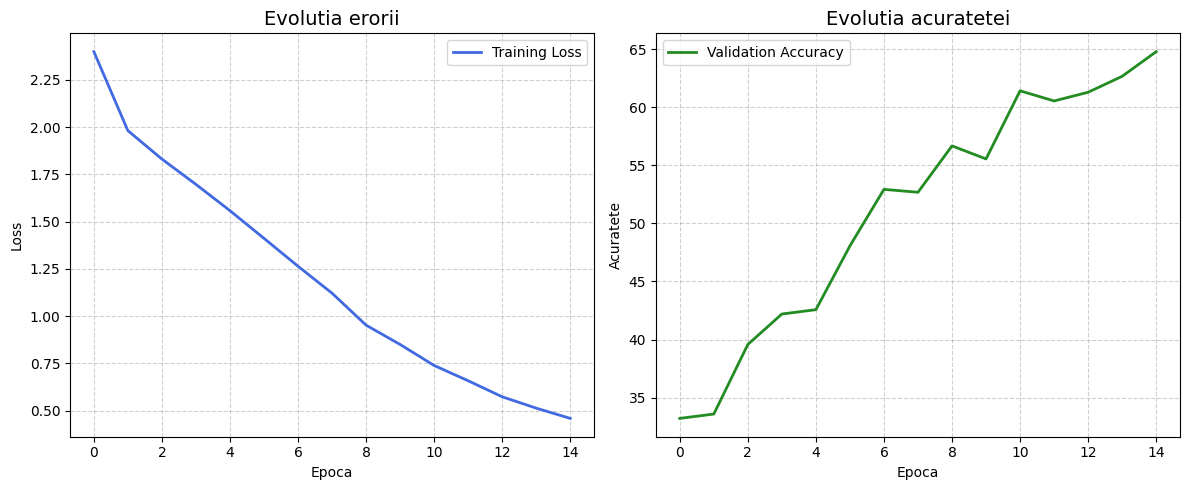

In [37]:
def plot_metrics(train_losses, valid_accuracies):
    plt.figure(figsize=(12, 5))

    # grafic pentru loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Training Loss', color='royalblue', linewidth=2)
    plt.title('Evolutia erorii', fontsize=14)
    plt.xlabel('Epoca')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # grafic pentru acuratete
    plt.subplot(1, 2, 2)
    plt.plot(valid_accuracies, label='Validation Accuracy', color='forestgreen', linewidth=2)
    plt.title('Evolutia acuratetei', fontsize=14)
    plt.xlabel('Epoca')
    plt.ylabel('Acuratete')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.savefig('rezultate_antrenare.png') 
    plt.show()

plot_metrics(train_losses, valid_accuracies)

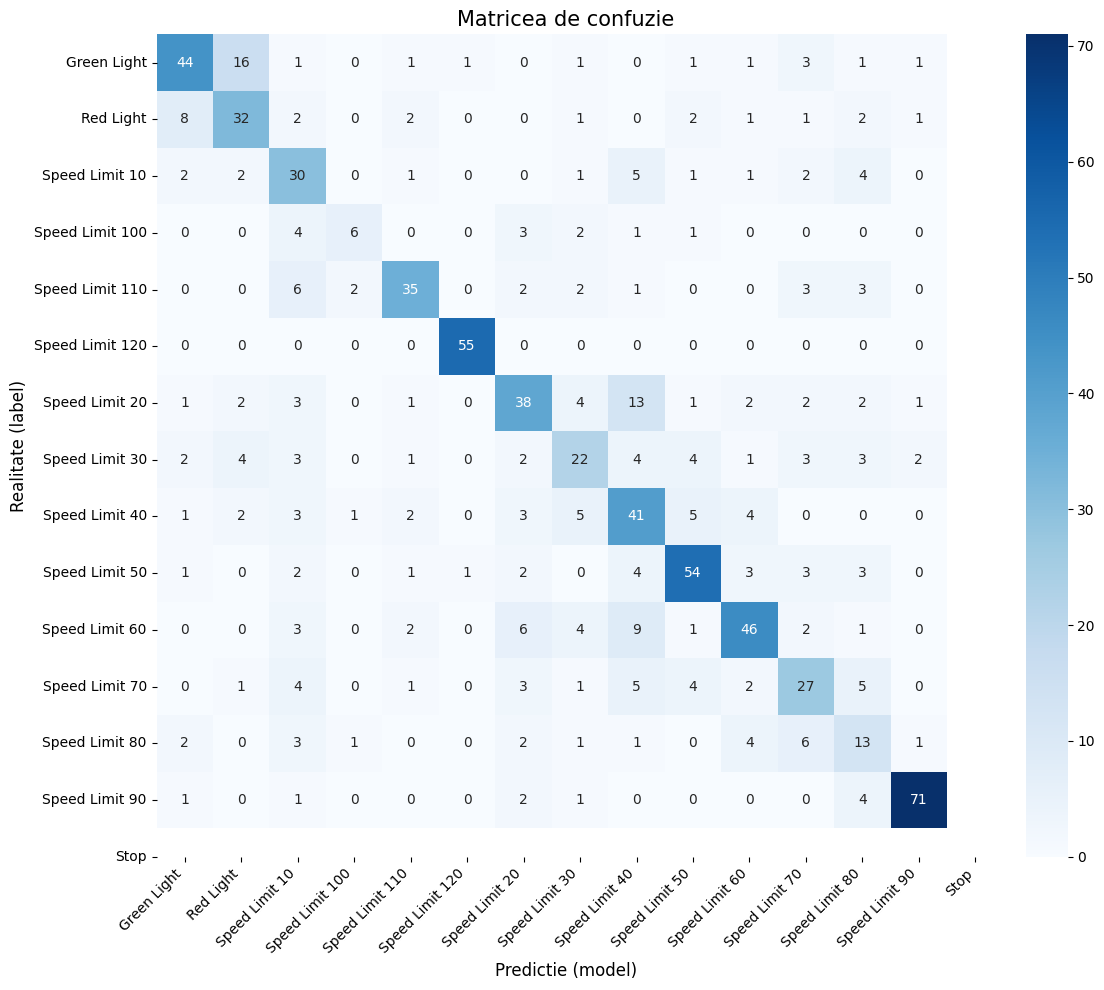

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model,loader,classes):
    all_preds = []
    all_labels = []
    model.eval()
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predictie (model)', fontsize=12)
    plt.ylabel('Realitate (label)', fontsize=12)
    plt.title('Matricea de confuzie', fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('matrice_confuzie.png')
    plt.show()

plot_confusion_matrix(model, valid_loader, classes)



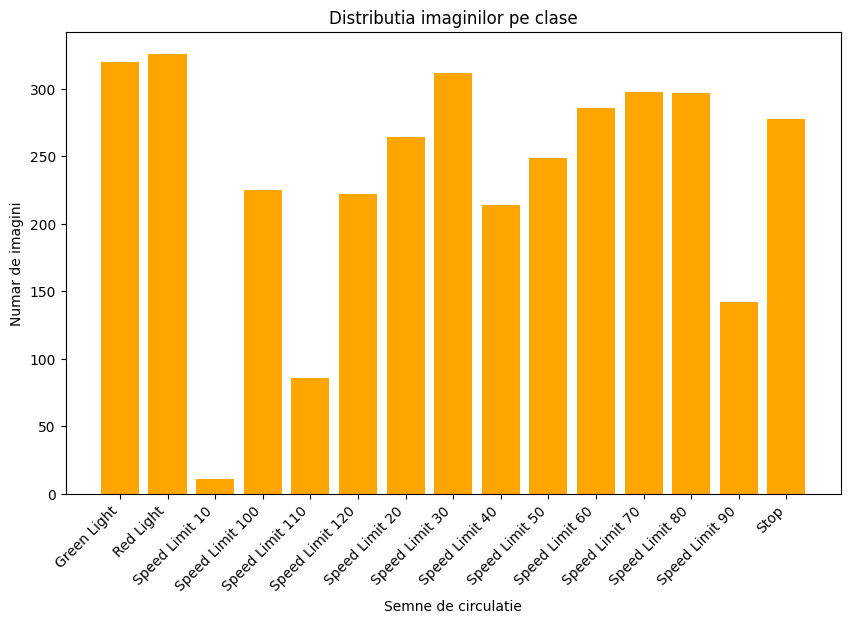

In [39]:
def plot_data_distribution(dataset, classes):
    labels = [label for _, label in dataset]
    counts = [labels.count(i) for i in range(len(classes))]
    
    plt.figure(figsize=(10, 6))
    plt.bar(classes, counts, color='orange')
    plt.title('Distributia imaginilor pe clase')
    plt.xlabel('Semne de circulatie')
    plt.ylabel('Numar de imagini')
    plt.xticks(rotation=45, ha='right')
    plt.show()

plot_data_distribution(train_dataset, classes)

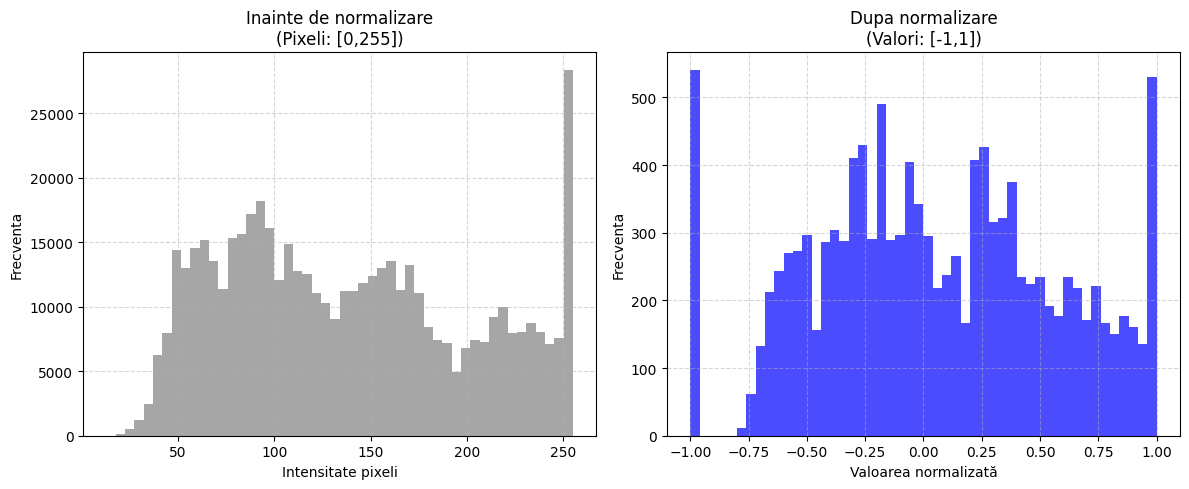

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_intensity_histogram(image_path):
    
    raw_img = Image.open(image_path).convert("RGB")
    raw_array = np.array(raw_img).flatten() 

    tensor_img = transform(raw_img)
    tensor_array = tensor_img.numpy().flatten()

    plt.figure(figsize=(12, 5))

    
    plt.subplot(1, 2, 1)
    plt.hist(raw_array, bins=50, color='gray', alpha=0.7)
    plt.title('Inainte de normalizare\n(Pixeli: [0,255])')
    plt.xlabel('Intensitate pixeli')
    plt.ylabel('Frecventa')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.subplot(1, 2, 2)
    plt.hist(tensor_array, bins=50, color='blue', alpha=0.7)
    plt.title('Dupa normalizare\n(Valori: [-1,1])')
    plt.xlabel('Valoarea normalizată')
    plt.ylabel('Frecventa')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('histograma_intensitate.png')
    plt.show()


plot_intensity_histogram('test/images/00000_00001_00016_png.rf.2818a0160369aa9d2465007de479d6d3.jpg')

In [18]:
pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [19]:
from torchsummary import summary

summary(model, input_size=(3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 64, 64]             448
              ReLU-2           [-1, 16, 64, 64]               0
         MaxPool2d-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           4,640
              ReLU-5           [-1, 32, 32, 32]               0
         MaxPool2d-6           [-1, 32, 16, 16]               0
            Conv2d-7           [-1, 64, 16, 16]          18,496
              ReLU-8           [-1, 64, 16, 16]               0
         MaxPool2d-9             [-1, 64, 8, 8]               0
           Linear-10                  [-1, 128]         524,416
             ReLU-11                  [-1, 128]               0
           Linear-12                   [-1, 15]           1,935
Total params: 549,935
Trainable params: 549,935
Non-trainable params: 0
-------------------------------